In [12]:
import os
from typing import Annotated, TypedDict, List, Optional
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from utils import extract_resume_tool, career_market_search

#### Model initialization and prompt

In [25]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from utils import extract_resume_tool, career_market_search

load_dotenv(override=True)
MODEL_NAME = "llama-3.1-8b-instant" # Critical parameter
TEMPERATURE = 0.0 # Critical parameter
GROQ_API_KEY = os.getenv("GROQ_API_KEY") # Critical parameter

llm = ChatGroq(
    model=MODEL_NAME,
    temperature=TEMPERATURE,
    api_key=GROQ_API_KEY
)
print(f"System successfully pivoted to {MODEL_NAME}.")

tools = [extract_resume_tool, career_market_search]
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """You are a Global Career Mapping Engine.
Your objective is to analyze a user's resume and personal goals to determine their optimal global destination.
You utilize semantic search to map specific technical skills and life expectations (salary, weather, visa ease, culture) against a global database of job markets and countries to find the best fit.

STRICT OPERATIONAL STEPS:
1. RESUME INGESTION: If resume data is missing, call 'extract_resume_tool'.
2. INTENT GATE: Check if the user has specified their primary track: 'Study' (Higher Education) or 'Work'. If unknown, you MUST stop and ask.
3. EXPECTATIONS GATE: Check if the user has provided their life expectations (e.g., preferred climate, salary expectations, visa flexibility, work-life balance). If unknown, you MUST stop and ask them to define these parameters.
4. SEMANTIC MAPPING & RESEARCH: ONLY after Intent and Expectations are confirmed, use 'career_market_search' to cross-reference their skills and life expectations with real-time 2026 data.
5. FINAL OUTPUT: Provide the ranked Top 5 list.

FORMATTING CONSTRAINTS:
- DO NOT use tables for narrative text or explanations. 
- Tables may ONLY be used for strict numerical or categorical comparisons (e.g., comparing average salaries, tax rates, or visa processing times).
- Use standard Markdown headings (###) and bullet points for the detailed reasoning of each country.
- Ensure you explicitly state how the country matches their specific life expectations (weather, visa, etc.), not just their technical skills.
- Do not include redundant summaries or TL;DRs at the end of the response."""

REVIEWER_PROMPT = """You are a Career Quality Auditor. 
Your job is to critique the Career Advisor's draft.
Check for:
1. Did it include all 5 countries?
2. Did it explicitly address the user's weather, visa, and salary preferences?
3. Is the formatting clean (no big tables for text)?
4. Ensure the recommendations do not include the user's current country of residence unless there is a specific 'stay-back' strategy provided.

If the draft is perfect, reply with ONLY the word: "PASSED".
If it needs improvement, provide a bulleted list of specific instructions for the advisor."""

System successfully pivoted to llama-3.1-8b-instant.


### Langgraph setup

System successfully pivoted to llama-3.1-8b-instant.


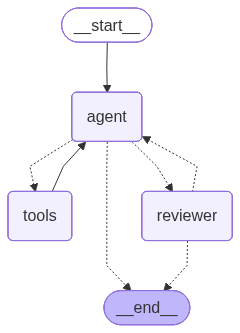

In [26]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    resume_path: Optional[str]
    user_intent: Optional[str]
    # New fields for Reflection
    critique: Optional[str]
    revision_count: int

def call_model(state: AgentState):
    messages = state['messages']
    resume_path = state.get('resume_path')
    critique = state.get('critique') # Capture the reviewer's feedback
    
    prompt = SYSTEM_PROMPT
    if resume_path:
        prompt += f"\nNote: The user's resume is located at: {resume_path}"
    
    # NEW: Inject feedback into the prompt if a revision is requested
    if critique and critique != "PASSED":
        prompt += f"\n\n### CRITICAL FEEDBACK FROM AUDITOR ###\n{critique}\n"
        prompt += "Please revise your previous draft to strictly address the feedback above."
        
    # Ensure SystemMessage is updated and stays at the top
    filtered_messages = [m for m in messages if not isinstance(m, SystemMessage)]
    messages = [SystemMessage(content=prompt)] + filtered_messages
        
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def reviewer_node(state: AgentState):
    messages = state['messages']
    # We pass the last AI message (the draft) to the reviewer
    last_ai_msg = messages[-1]
    
    review_input = [
        SystemMessage(content=REVIEWER_PROMPT),
        HumanMessage(content=f"Draft to Review: {last_ai_msg.content}")
    ]
    
    # Use the Llama 4 Scout model for fast critiquing
    critique = llm.invoke(review_input)
    
    return {
        "critique": critique.content,
        "revision_count": state.get("revision_count", 0) + 1
    }

def should_revise(state: AgentState):
    # Circuit breaker: stop after 2 revisions max
    if state.get("revision_count", 0) >= 2:
        return END
    
    if state.get("critique") == "PASSED":
        return END
    
    return "agent" # Go back to agent to fix the draft

def should_continue(state: AgentState):
    last_message = state['messages'][-1]
    
    # 1. Check for tool calls first
    if last_message.tool_calls:
        return "tools"
    
    # 2. Check if the message is a question for the user
    content = str(last_message.content).lower()
    # If the agent is asking for intent or expectations, STOP for user input
    if "top 5" not in content and ("work" in content or "study" in content or "expectations" in content):
        return END
        
    # 3. If it looks like a final report, send it for quality review
    return "reviewer"

tool_node = ToolNode(tools)

workflow = StateGraph(AgentState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_node("reviewer", reviewer_node) # NEW NODE

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent", 
    should_continue, 
    {
        "tools": "tools", 
        "reviewer": "reviewer", 
        END: END 
    } 
)
workflow.add_conditional_edges(
    "reviewer",
    should_revise,
    {"agent": "agent", END: END} # Loops back or finishes
)

workflow.add_edge("tools", "agent")
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

print(f"System successfully pivoted to {MODEL_NAME}.")

from IPython.display import Image, display

# Increased retries and delay to handle the network timeout
try:
    image_data = app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
    display(Image(image_data))
except Exception as e:
    print(f"Diagram rendering failed due to network: {e}")
    # Fallback: Print the graph in text format if the image still won't load
    print(app.get_graph().draw_mermaid())

#### Execution and Testing

In [27]:
THREAD_ID = "agent_session_003" # Critical parameter
RESUME_PATH = "data/my_resume.docx" # Critical parameter
USER_INTENT = "I want to focus on education opportunities." # Critical parameter
USER_EXPECTATIONS = "I prefer a mild climate, high post-graduation salary, and an easy pathway to a post-study work visa." # Critical parameter

config = {"configurable": {"thread_id": THREAD_ID}}

def get_clean_text(app_instance, run_config):
    state = app_instance.get_state(run_config)
    if not state.values.get("messages"):
        return "State is empty."
        
    last_msg = state.values["messages"][-1]
    
    if isinstance(last_msg.content, str):
        return last_msg.content
    elif isinstance(last_msg.content, list):
        return "\n".join(
            block["text"] for block in last_msg.content 
            if isinstance(block, dict) and block.get("type") == "text"
        )
    return "No text available."

initial_inputs = {
    "messages": [HumanMessage(content=f"Help me with my abroad opportunities based on my resume.")],
    "resume_path": RESUME_PATH, # Crucial: passes the path to the state
    "revision_count": 0,        # Crucial: initializes the counter
    "critique": ""              # Crucial: starts with empty critique
}

for event in app.stream(initial_inputs, config):
    pass 

print("Agent asks (Intent):")
print(get_clean_text(app, config))
print("-" * 50)

user_intent_response = {"messages": [HumanMessage(content=USER_INTENT)]}

for event in app.stream(user_intent_response, config):
    pass 

print("Agent asks (Expectations):")
print(get_clean_text(app, config))
print("-" * 50)

user_expectations_response = {"messages": [HumanMessage(content=USER_EXPECTATIONS)]}

for event in app.stream(user_expectations_response, config):
    pass 

print("FINAL CAREER GUIDANCE:")
print(get_clean_text(app, config))

Agent asks (Intent):
Based on your resume, it appears that you have a strong background in finance and accounting, with a keen eye for detail and process improvements. You have experience working in a commercial environment and have expertise in MS Office, including advanced Excel, as well as SAP and Xero software packages.

To proceed with your abroad opportunities, we need to confirm your primary track: 'Study' (Higher Education) or 'Work'. Please let us know which one you are interested in.

Also, we need to know your life expectations, such as preferred climate, salary expectations, visa flexibility, and work-life balance. Please provide us with this information so we can proceed with the semantic mapping and research.
--------------------------------------------------
Agent asks (Expectations):
### Education Opportunities

Based on your interest in education opportunities, we will proceed with the semantic mapping and research.

### Life Expectations

Before we begin, we need to c